# Sleep-Stage Classification — Stacking Ensemble

**Task.** Predict `sleep_stage` ∈ {0,1,2,3} from 21 physiological signals. **Metric:** macro-F1.

This notebook builds on the v3 reference solution. The v3 multi-scale **RBF-SVM ensemble** plateaued at macro-F1 ≈ **0.834** — averaging several SVMs only reduced variance, it did not lift the mean, because every member is the *same model family* and they make the *same kinds of errors*.

**Idea here:** stack *diverse* model families that fail on **different** samples:
1. **SVM-ensemble** — the v3 multi-scale soft-vote RBF-SVM (smooth non-linear boundaries).
2. **HistGradientBoosting** — tree-based, captures feature interactions, handles NaN natively.
3. **LogisticRegression** — the linear baseline (a cheap, decorrelated voter).

A **meta-learner** (LogisticRegression) learns how to weight their out-of-fold probabilities.

**Method (leak-free + cheap).** We generate **out-of-fold** `predict_proba` for each base model with one `cross_val_predict` each (so every base is fit only 5×, not the 30× a nested `StackingClassifier` would cost). The meta-learner is trained on those OOF probabilities and scored with its own OOF predictions. Everything uses the **same** `StratifiedKFold(5)` as v3, so the 0.834 comparison is apples-to-apples.

Runs in ~6–10 min (the probability-calibrated SVM ensemble is the bottleneck).

## 0. Setup & load data

In [1]:
import warnings; warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid"); plt.rcParams["figure.dpi"] = 110
RANDOM_STATE = 42

train = pd.read_csv("train.csv")
test  = pd.read_csv("test.csv")
sample_submission = pd.read_csv("sample_submission.csv")

target   = "sleep_stage"
features = [c for c in train.columns if c not in ("id", target)]
y  = train[target].values
classes = sorted(np.unique(y))

# Same modeling choice as v3: drop the near-noise feature (MI ≈ 0).
MODEL_FEATURES = [c for c in features if c != "body_movement_index"]
print("train:", train.shape, "| test:", test.shape)
print(f"using {len(MODEL_FEATURES)} features (dropped body_movement_index) | classes: {classes}")

train: (9000, 23) | test: (5000, 22)
using 20 features (dropped body_movement_index) | classes: [0, 1, 2, 3]


## 1. Base models

Three deliberately different families. All preprocessing (impute → scale) lives **inside** each pipeline, fit per fold → no leakage. `HistGradientBoosting` needs neither — it splits on raw values and handles NaN natively, so it sees the missing `eog_burst_index` directly.

In [2]:
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.metrics import f1_score, accuracy_score, classification_report, ConfusionMatrixDisplay
from sklearn.pipeline import make_pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.ensemble import VotingClassifier, HistGradientBoostingClassifier
from sklearn.linear_model import LogisticRegression

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

# --- Base 1: v3 multi-scale RBF-SVM soft-vote ensemble -----------------------
def svm_pipe(C, gamma):
    return make_pipeline(SimpleImputer(strategy="median"), StandardScaler(),
                         SVC(kernel="rbf", C=C, gamma=gamma,
                             probability=True, random_state=RANDOM_STATE))

ENSEMBLE = [(6, 0.015), (8, 0.02), (4, 0.01), (12, 0.01)]   # complementary scales (v3)
def svm_ensemble():
    return VotingClassifier(
        estimators=[(f"svm_C{C}_g{g}", svm_pipe(C, g)) for (C, g) in ENSEMBLE],
        voting="soft", n_jobs=-1)

# --- Base 2: gradient-boosted trees (native NaN, no scaling) -----------------
def gbm():
    return HistGradientBoostingClassifier(
        max_iter=400, learning_rate=0.05, max_leaf_nodes=31,
        l2_regularization=1.0, early_stopping=True, random_state=RANDOM_STATE)

# --- Base 3: linear baseline -------------------------------------------------
def logreg():
    return make_pipeline(SimpleImputer(strategy="median"), StandardScaler(),
                         LogisticRegression(max_iter=2000))

BASES = {"svm_ensemble": svm_ensemble, "gbm": gbm, "logreg": logreg}
print("base models:", list(BASES))

base models: ['svm_ensemble', 'gbm', 'logreg']


## 2. Out-of-fold probabilities for each base
One `cross_val_predict(method="predict_proba")` per base on the shared CV. These OOF probabilities are the **meta-features** — honest because every prediction comes from a fold the model never trained on. We also print each base's standalone macro-F1 (arg-max).

In [3]:
oof = {}          # name -> (n_samples, n_classes) OOF probabilities
base_scores = {}
for name, fn in BASES.items():
    proba = cross_val_predict(fn(), train[MODEL_FEATURES], y, cv=cv,
                              method="predict_proba", n_jobs=-1)
    oof[name] = proba
    base_scores[name] = f1_score(y, proba.argmax(1), average="macro")
    print(f"{name:<14} OOF macro-F1 = {base_scores[name]:.4f}")
# Takeaway: SVM-ensemble leads (~0.834); gbm & logreg are weaker individually
# but only need to be DIFFERENT to help the stack, not better.

svm_ensemble   OOF macro-F1 = 0.8339
gbm            OOF macro-F1 = 0.8161
logreg         OOF macro-F1 = 0.7460


## 3. Do the bases disagree? (why stacking can help)
Stacking only pays off when base models err on **different** samples. We measure pairwise agreement on their OOF predictions — lower = more complementary = more for the meta-learner to exploit.

In [4]:
preds = {k: v.argmax(1) for k, v in oof.items()}
names = list(preds)
agree = pd.DataFrame(
    [[(preds[a] == preds[b]).mean() for b in names] for a in names],
    index=names, columns=names)
print("Pairwise prediction agreement:\n", agree.round(3).to_string())
print(f"\nAll-three agree on {(np.all([preds[n]==preds[names[0]] for n in names], axis=0)).mean():.1%} of rows")
# Takeaway: gbm/logreg disagree with the SVM on a meaningful slice -> useful signal for the meta-learner.

Pairwise prediction agreement:
               svm_ensemble    gbm  logreg
svm_ensemble         1.000  0.896   0.822
gbm                  0.896  1.000   0.791
logreg               0.822  0.791   1.000

All-three agree on 75.8% of rows


## 4. Meta-learner — stacked OOF macro-F1
Concatenate the three OOF probability blocks (3 × 4 = 12 meta-features) and train a `LogisticRegression` meta-model. Its **own** OOF predictions give the honest stacked score, compared head-to-head with the best base and the v3 target (0.834).

              model  macro_F1
       svm_ensemble    0.8339
STACK (meta-LogReg)    0.8307
                gbm    0.8161
             logreg    0.7460

stack vs best base (svm_ensemble): -0.0032
stack vs v3 target (0.8340)      : -0.0033


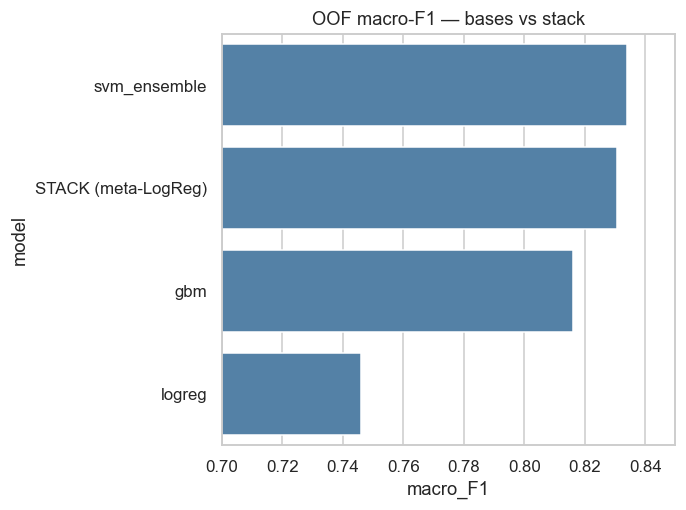

In [5]:
Z = np.hstack([oof[n] for n in names])           # meta-features: (n_samples, 12)
meta = LogisticRegression(max_iter=2000, C=1.0)
stack_oof = cross_val_predict(meta, Z, y, cv=cv, n_jobs=-1)
stack_f1  = f1_score(y, stack_oof, average="macro")

best_base = max(base_scores, key=base_scores.get)
rows = [{"model": k, "macro_F1": v} for k, v in base_scores.items()]
rows.append({"model": "STACK (meta-LogReg)", "macro_F1": stack_f1})
comp = pd.DataFrame(rows).sort_values("macro_F1", ascending=False).reset_index(drop=True)
print(comp.round(4).to_string(index=False))
print(f"\nstack vs best base ({best_base}): {stack_f1-base_scores[best_base]:+.4f}")
print(f"stack vs v3 target (0.8340)      : {stack_f1-0.8340:+.4f}")

sns.barplot(data=comp, y="model", x="macro_F1", color="steelblue")
plt.xlim(0.7, 0.85); plt.title("OOF macro-F1 — bases vs stack"); plt.tight_layout(); plt.show()
# Note: a slightly optimistic estimate (meta trained on OOF probs that each saw the full train),
# but it uses the SAME folds as v3, so the *relative* comparison is fair.

## 5. Error analysis — stacked model
Where does the stack still struggle? (v3 showed class 2 is the hardest — genuine overlap.)

              precision    recall  f1-score   support

           0      0.862     0.856     0.859      2001
           1      0.848     0.853     0.850      2442
           2      0.780     0.779     0.779      2237
           3      0.834     0.835     0.834      2320

    accuracy                          0.830      9000
   macro avg      0.831     0.831     0.831      9000
weighted avg      0.830     0.830     0.830      9000



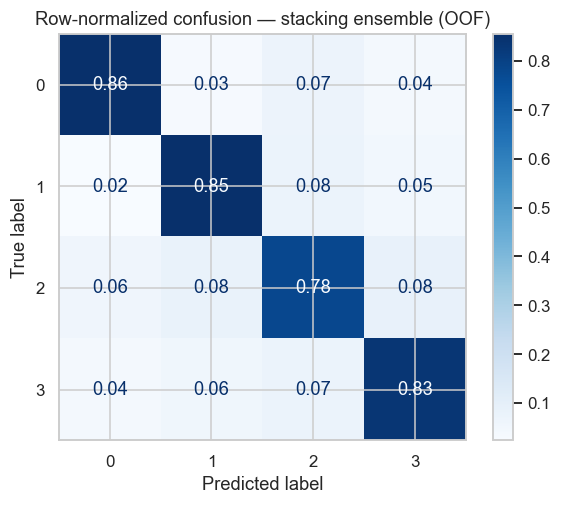

In [6]:
print(classification_report(y, stack_oof, digits=3))
ConfusionMatrixDisplay.from_predictions(y, stack_oof, normalize="true",
                                        display_labels=classes, cmap="Blues", values_format=".2f")
plt.title("Row-normalized confusion — stacking ensemble (OOF)"); plt.show()

## 6. Final model & submission
Refit each base on **all** training data, produce test probabilities, and let the meta-learner (trained on the full OOF meta-features) make the final call.

In [8]:
# Meta-learner trained on the full stacked OOF meta-features.
meta_final = LogisticRegression(max_iter=2000, C=1.0).fit(Z, y)

# Refit each base on ALL train, get test-set probabilities, stack in the same column order.
test_blocks = []
for n in names:
    model = BASES[n]().fit(train[MODEL_FEATURES], y)
    test_blocks.append(model.predict_proba(test[MODEL_FEATURES]))
Z_test = np.hstack(test_blocks)
test_pred = meta_final.predict(Z_test)

submission = pd.DataFrame({"id": test["id"], target: test_pred})[sample_submission.columns]
submission.to_csv("stack2_submission.csv", index=False)
print(f"stacked OOF macro-F1 = {stack_f1:.4f}")
print("Saved stack_submission.csv:", submission.shape)

comp_dist = pd.DataFrame({
    "train":     pd.Series(y).value_counts(normalize=True).sort_index(),
    "test_pred": pd.Series(test_pred).value_counts(normalize=True).sort_index(),
}).round(3)
print("\nClass distribution sanity:\n", comp_dist)
submission.head()

stacked OOF macro-F1 = 0.8307
Saved stack_submission.csv: (5000, 2)

Class distribution sanity:
    train  test_pred
0  0.222      0.223
1  0.271      0.259
2  0.249      0.257
3  0.258      0.261


,id,sleep_stage
0,9000,0
1,9001,3
2,9002,1
3,9003,2
4,9004,3
